In [2]:
import pandas as pd
import numpy as np
import torch
from transformers import BertTokenizer, BertForSequenceClassification
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import torch.optim as optim
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from collections import Counter

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [3]:
df = pd.read_csv("news.csv")

print(df.columns)
print(df.head())
print(df["label"].value_counts())

Index(['Unnamed: 0', 'title', 'text', 'label'], dtype='object')
   Unnamed: 0                                              title  \
0        8476                       You Can Smell Hillary’s Fear   
1       10294  Watch The Exact Moment Paul Ryan Committed Pol...   
2        3608        Kerry to go to Paris in gesture of sympathy   
3       10142  Bernie supporters on Twitter erupt in anger ag...   
4         875   The Battle of New York: Why This Primary Matters   

                                                text label  
0  Daniel Greenfield, a Shillman Journalism Fello...  FAKE  
1  Google Pinterest Digg Linkedin Reddit Stumbleu...  FAKE  
2  U.S. Secretary of State John F. Kerry said Mon...  REAL  
3  — Kaydee King (@KaydeeKing) November 9, 2016 T...  FAKE  
4  It's primary day in New York and front-runners...  REAL  
label
REAL    3171
FAKE    3164
Name: count, dtype: int64


In [4]:
df["label"] = df["label"].str.upper().str.strip()
df["label"] = df["label"].map({"REAL": 1, "FAKE": 0})

df = df[["text", "label"]]
df = df.dropna()
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

print(df.shape)
print(df["label"].value_counts())
print(df.head())

(6335, 2)
label
1    3171
0    3164
Name: count, dtype: int64
                                                text  label
0  Will Trump pull a Brexit times ten? What would...      0
1  Clintons Are Under Multiple FBI Investigations...      0
2  Dispatches from Eric Zuesse This piece is cros...      0
3  Print \n[Ed. – Every now and then the facade c...      0
4  Nanny In Jail After Force Feeding Baby To Deat...      0


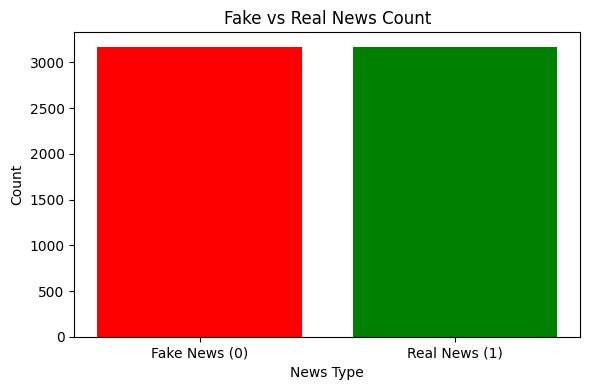

In [5]:
plt.figure(figsize=(6, 4))
counts = df["label"].value_counts()
plt.bar(["Fake News (0)", "Real News (1)"], counts.values, color=["red", "green"])
plt.title("Fake vs Real News Count")
plt.xlabel("News Type")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

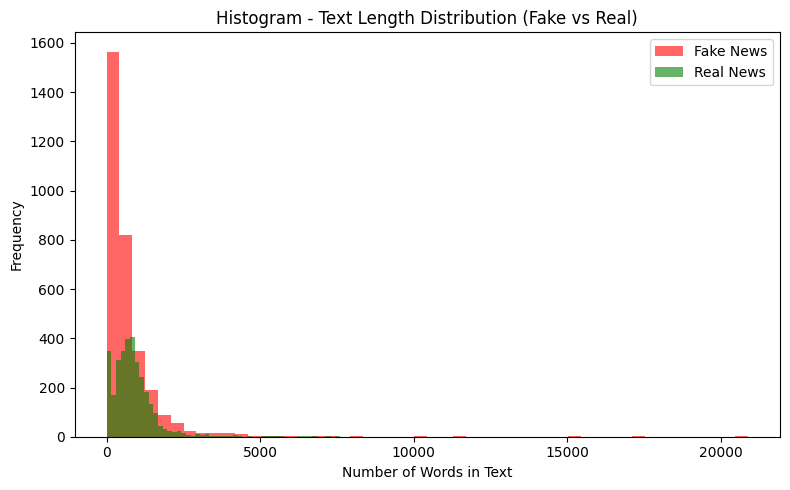

In [6]:
df["text_length"] = df["text"].apply(lambda x: len(x.split()))

plt.figure(figsize=(8, 5))
plt.hist(df[df["label"] == 0]["text_length"], bins=50, color="red", alpha=0.6, label="Fake News")
plt.hist(df[df["label"] == 1]["text_length"], bins=50, color="green", alpha=0.6, label="Real News")
plt.title("Histogram - Text Length Distribution (Fake vs Real)")
plt.xlabel("Number of Words in Text")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.show()

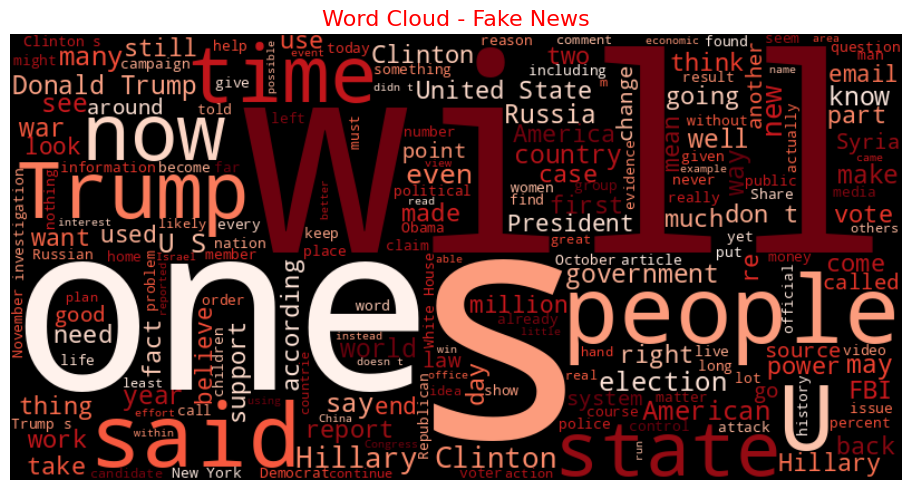

In [7]:
fake_text = " ".join(df[df["label"] == 0]["text"].tolist())

wordcloud_fake = WordCloud(
    width=800,
    height=400,
    background_color="black",
    colormap="Reds",
    max_words=200
).generate(fake_text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud_fake, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud - Fake News", fontsize=16, color="red")
plt.tight_layout()
plt.show()

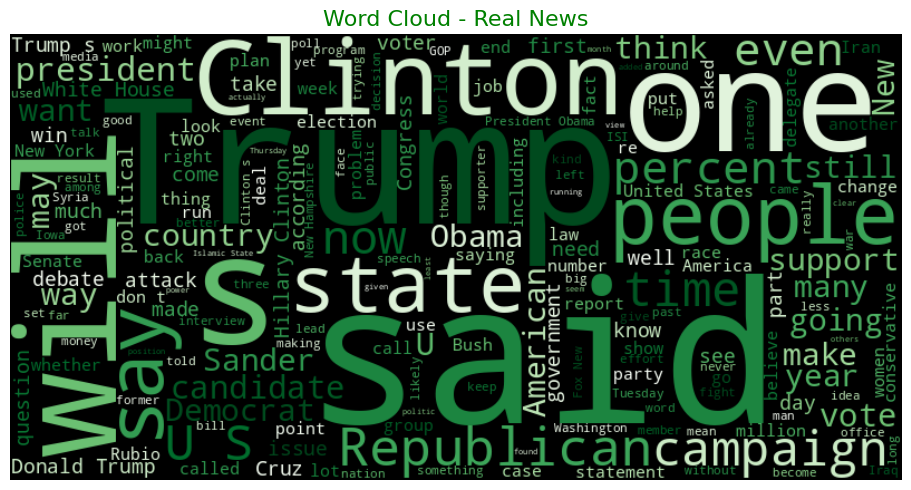

In [8]:
real_text = " ".join(df[df["label"] == 1]["text"].tolist())

wordcloud_real = WordCloud(
    width=800,
    height=400,
    background_color="black",
    colormap="Greens",
    max_words=200
).generate(real_text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud_real, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud - Real News", fontsize=16, color="green")
plt.tight_layout()
plt.show()

In [9]:
train_texts, test_texts, train_labels, test_labels = train_test_split(
    df["text"].tolist(),
    df["label"].tolist(),
    test_size=0.2,
    random_state=42
)

print("Train size:", len(train_texts))
print("Test size:", len(test_texts))

Train size: 5068
Test size: 1267


In [10]:
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

In [12]:
class NewsDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            max_length=self.max_len,
            padding="max_length",
            truncation=True,
            return_tensors="pt"
        )
        return {
            "input_ids": encoding["input_ids"].squeeze(),
            "attention_mask": encoding["attention_mask"].squeeze(),
            "label": torch.tensor(self.labels[idx], dtype=torch.long)
        }

In [13]:
train_dataset = NewsDataset(train_texts, train_labels, tokenizer)
test_dataset = NewsDataset(test_texts, test_labels, tokenizer)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

print("Train batches:", len(train_loader))
print("Test batches:", len(test_loader))

Train batches: 317
Test batches: 80


In [14]:
model = BertForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=2
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

print("Model loaded on:", device)

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model loaded on: cuda


In [15]:
optimizer = optim.AdamW(model.parameters(), lr=2e-5)

In [16]:
EPOCHS = 3
epoch_losses = []

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0

    for batch in train_loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["label"].to(device)

        optimizer.zero_grad()

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )

        loss = outputs.loss
        total_loss += loss.item()

        loss.backward()
        optimizer.step()

    avg_loss = total_loss / len(train_loader)
    epoch_losses.append(avg_loss)
    print(f"Epoch {epoch+1}/{EPOCHS} - Loss: {avg_loss:.4f}")

Epoch 1/3 - Loss: 0.2050
Epoch 2/3 - Loss: 0.0667
Epoch 3/3 - Loss: 0.0328


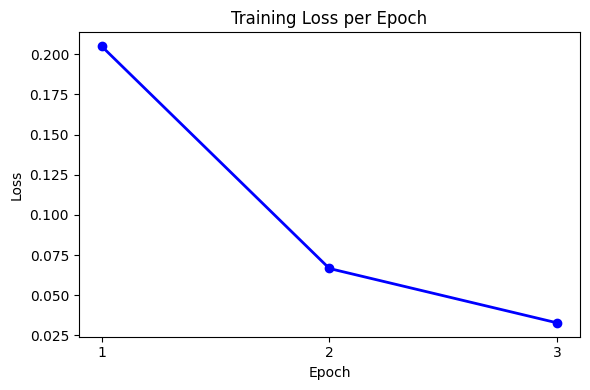

In [17]:
plt.figure(figsize=(6, 4))
plt.plot(range(1, EPOCHS+1), epoch_losses, marker="o", color="blue", linewidth=2)
plt.title("Training Loss per Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.xticks(range(1, EPOCHS+1))
plt.tight_layout()
plt.show()

In [18]:
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for batch in test_loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["label"].to(device)

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        preds = torch.argmax(outputs.logits, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

accuracy = accuracy_score(all_labels, all_preds)
print("Accuracy:", accuracy)
print(classification_report(all_labels, all_preds, target_names=["Fake", "Real"]))

Accuracy: 0.9502762430939227
              precision    recall  f1-score   support

        Fake       0.93      0.98      0.95       655
        Real       0.97      0.92      0.95       612

    accuracy                           0.95      1267
   macro avg       0.95      0.95      0.95      1267
weighted avg       0.95      0.95      0.95      1267



In [24]:
model.eval()
encoding = tokenizer(
    "The president signed the new economic bill today in the White House.",
    max_length=128,
    padding="max_length",
    truncation=True,
    return_tensors="pt"
)
input_ids = encoding["input_ids"].to(device)
attention_mask = encoding["attention_mask"].to(device)

with torch.no_grad():
    outputs = model(input_ids=input_ids, attention_mask=attention_mask)
    logits = outputs.logits
    probs = torch.softmax(logits, dim=1)
    print("Fake probability:", probs[0][0].item())
    print("Real probability:", probs[0][1].item())

Fake probability: 0.005307203158736229
Real probability: 0.9946927428245544


In [25]:
def predict(text):
    model.eval()
    encoding = tokenizer(
        text,
        max_length=128,
        padding="max_length",
        truncation=True,
        return_tensors="pt"
    )
    input_ids = encoding["input_ids"].to(device)
    attention_mask = encoding["attention_mask"].to(device)

    with torch.no_grad():
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        logits = outputs.logits
        probs = torch.softmax(logits, dim=1)
        fake_prob = probs[0][0].item()
        real_prob = probs[0][1].item()
        pred = torch.argmax(logits, dim=1).item()

    print(f"Fake Probability: {fake_prob:.4f}")
    print(f"Real Probability: {real_prob:.4f}")

    if pred == 1:
        return "Real News"
    else:
        return "Fake News"

In [26]:
real_sample = "The president signed the new economic bill today in the White House."
print(predict(real_sample))

fake_sample = "Aliens have landed on Earth and government is hiding it."
print(predict(fake_sample))

Fake Probability: 0.0053
Real Probability: 0.9947
Real News
Fake Probability: 0.9935
Real Probability: 0.0065
Fake News


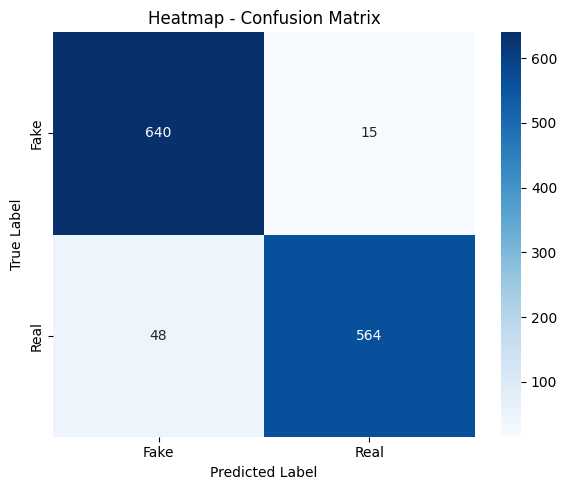

In [19]:
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Fake", "Real"],
            yticklabels=["Fake", "Real"])
plt.title("Heatmap - Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

In [29]:
def predict(text):
    model.eval()
    encoding = tokenizer(
        text,
        max_length=128,
        padding="max_length",
        truncation=True,
        return_tensors="pt"
    )
    input_ids = encoding["input_ids"].to(device)
    attention_mask = encoding["attention_mask"].to(device)

    with torch.no_grad():
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        pred = torch.argmax(outputs.logits, dim=1).item()

    return "Real News" if pred == 1 else "Fake News"

texts = [
    "Bill Gates is putting microchips in COVID vaccines to control humans.",
    "The Federal Reserve raised interest rates by 0.25 percent on Wednesday.",
    "NASA confirms that the Earth is actually flat and has been hiding it for years."
]

for t in texts:
    print(t)
    print(predict(t))
    print("------")

Bill Gates is putting microchips in COVID vaccines to control humans.
Fake News
------
The Federal Reserve raised interest rates by 0.25 percent on Wednesday.
Real News
------
NASA confirms that the Earth is actually flat and has been hiding it for years.
Fake News
------
